In [1]:
import polars as pl

In [2]:
df = pl.read_parquet("../data/results.parquet")

In [3]:
# One-way random-effects ICC(1) per [bioproject, col_name], computed from group summary stats.
# Each row's "positive" group is one level (col_value) of col_name; the rows form the groups.
# std_positive uses ddof=1 and is null for n=1, which contributes 0 to the within-group SS.
n = pl.col("count_positive").cast(pl.Float64)
m = pl.col("mean_positive")
s = pl.col("std_positive").fill_null(0.0)

icc = (
    df.group_by(["bioproject", "col_name"])
    .agg(
        k=pl.len(),
        N=n.sum(),
        sum_n2=(n**2).sum(),
        grand_mean=(n * m).sum() / n.sum(),
        ssw=((n - 1) * s**2).sum(),
        sum_nm2=(n * m**2).sum(),
    )
    .with_columns(ssb=pl.col("sum_nm2") - pl.col("N") * pl.col("grand_mean") ** 2)
    .with_columns(
        msb=pl.col("ssb") / (pl.col("k") - 1),
        msw=pl.col("ssw") / (pl.col("N") - pl.col("k")),
        # effective group size for unbalanced designs
        n0=(pl.col("N") - pl.col("sum_n2") / pl.col("N")) / (pl.col("k") - 1),
    )
    .with_columns(
        icc=pl.when((pl.col("k") >= 2) & (pl.col("N") > pl.col("k")))
        .then(
            (pl.col("msb") - pl.col("msw"))
            / (pl.col("msb") + (pl.col("n0") - 1) * pl.col("msw"))
        )
        .otherwise(None)
        .fill_nan(None)  # 0/0 when there is no variance at all
    )
    .select("bioproject", "col_name", "icc")
)

df = df.join(icc, on=["bioproject", "col_name"], how="left")
df.select("bioproject", "col_name", "icc").unique(["bioproject", "col_name"]).describe()

statistic,bioproject,col_name,icc
str,str,f64,f64
"""count""","""31485""",31485.0,18445.0
"""null_count""","""0""",0.0,13040.0
"""mean""",null,null,-0.076517
"""std""",null,null,0.7044
"""min""","""PRJDB10029""",null,-5.02639
"""25%""",null,null,-0.301683
"""50%""",null,null,-0.021399
"""75%""",null,null,0.280811
"""max""","""PRJNA946291""",null,1.0


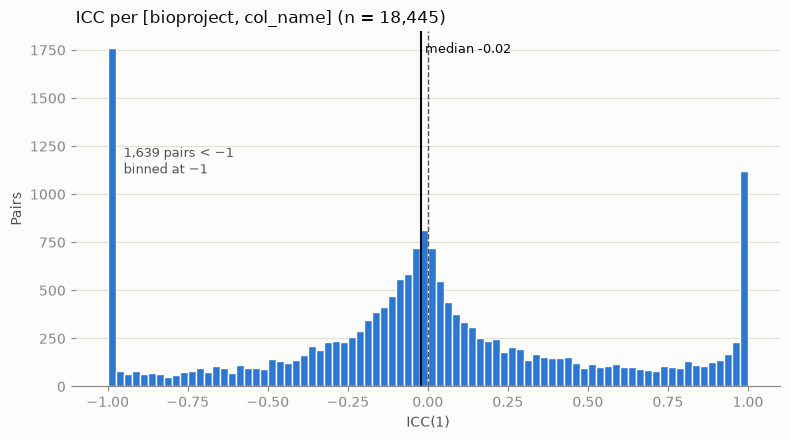

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# one ICC per [bioproject, col_name] pair, not per row
icc_vals = (
    df.unique(["bioproject", "col_name"]).get_column("icc").drop_nulls().to_numpy()
)
n_below = int((icc_vals < -1).sum())

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.hist(
    icc_vals.clip(-1, None),
    bins=np.linspace(-1, 1, 81),
    color="#2a78d6",
    edgecolor="#fcfcfb",
    linewidth=1,
)
ax.axvline(0, color="#52514e", linewidth=1, linestyle="--")
ax.axvline(np.median(icc_vals), color="#0b0b0b", linewidth=1.5)
ax.text(
    np.median(icc_vals), ax.get_ylim()[1] * 0.97, f" median {np.median(icc_vals):.2f}",
    color="#0b0b0b", va="top", fontsize=9,
)

ax.set_title(
    f"ICC per [bioproject, col_name] (n = {len(icc_vals):,})", loc="left", color="#0b0b0b"
)
ax.set_xlabel("ICC(1)", color="#52514e")
ax.set_ylabel("Pairs", color="#52514e")
ax.tick_params(colors="#898781")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#898781")
if n_below:
    ax.annotate(
        f"{n_below:,} pairs < −1\nbinned at −1", xy=(-1, 0), xytext=(-0.95, ax.get_ylim()[1] * 0.6),
        color="#52514e", fontsize=9,
    )
plt.tight_layout()
plt.show()

In [9]:
# sort by ICC, not including nulls, so that the top-ranked findings are at the top of the table
df = df.sort(["icc", "bioproject", "col_name"], descending=[True, False, False], nulls_last=True)
df.write_parquet("../data/results_ranked_icc.parquet")

In [ ]:
# find which row bioproject PRJNA809314 is in, displaying the full table of results for that bioproject
df.filter(pl.col("bioproject") == "PRJNA809314").select("bioproject", "col_name", "icc").head(15)

bioproject,col_name,icc
str,list[str],f64
"""PRJNA809314""","[""genotype_attrib""]",0.133738
"""PRJNA809314""","[""genotype_attrib""]",0.133738
"""PRJNA809314""","[""genotype_attrib""]",0.133738
"""PRJNA809314""","[""genotype_attrib""]",0.133738
"""PRJNA809314""","[""molecule_subtype_attrib""]",0.088565
…,…,…
"""PRJNA809314""","[""treatment_attrib""]",-0.03676
"""PRJNA809314""","[""treatment_attrib""]",-0.03676
"""PRJNA809314""","[""treatment_attrib""]",-0.03676
